In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import json
from datetime import datetime

## Draw multiple n_target graph

In [ ]:
n_source = 80
p = 200
K = 5
Ka = 2
h = 15
alpha = 0.05
T = 5
s_len = 10
s_vector = [0.5] * s_len
iteration = 1000
n_target_list = [50, 60, 70, 80]

config = {  
    "n_source":  n_source,
    "p": p,
    "K":  K,
    "Ka": Ka,
    "h": h,
    "alpha": alpha,
    "T": T,
    "s_len": s_len,
    "s_vector": s_vector,
    "iteration": iteration,
    "n_target_list": n_target_list
}

In [23]:
methods = {
        "DS": {
            "color": "green",
            "marker": "o",
            "linestyle": "-"
        },
        "Bonferroni": {
            "color": "purple",
            "marker": "o",
            "linestyle": "-"
        },
        "Naive": {
            "color": "teal", 
            "marker": "o",
            "linestyle": "-"
        },
        "No inference": {
            "color": "blue",
            "marker": "o",
            "linestyle": "-"
        },
        "CoRT-SI-oc": {
            "color": "gold",
            "marker": "o",
            "linestyle": "-"
        },
        "CoRT-SI": {
            "color": "red",
            "marker": "o",
            "linestyle": "-"
        }
    }

In [24]:
def get_experiment_results(config):
    filenames = {
        "CoRT-SI": "records/parametric_vis_records.json",
        "CoRT-SI-oc": "records/oc_vis_records.json",
        "DS": "records/data_splitting_vis_records.json",
        "Naive": "records/naive_vis_records.json",
        "No inference": "records/without_inference_vis_records.json",
        "Bonferroni": "records/bonferroni_vis_records.json"
    }
    
    experiment_results = {name: {"fpr": [], "tpr": []} for name in filenames.keys()}
    
    time_fmt = "%a %b %d %H:%M:%S %Y"

    for name, filename in filenames.items():
        try:
            with open(filename, 'r') as f:
                records = json.load(f)

            for n_t in config['n_target_list']:
                candidates = []
                
                for r in records:
                    rc = r['configs']
                    if (
                        config['n_source'] == rc['n_source'] and
                        config['p'] == rc['p'] and 
                        config['K'] == rc['K'] and
                        config['Ka'] == rc['Ka'] and
                        config['h'] == rc['h'] and
                        config['alpha'] == rc['alpha'] and
                        config['T'] == rc['T'] and
                        config['s_len'] == rc['s_len'] and
                        config['s_vector'] == rc['s_vector'] and
                        config['iteration'] == rc['iteration'] and
                        n_t == rc['n_target']
                    ):
                        candidates.append(r)

                if candidates:
                    latest_record = max(
                        candidates, 
                        key=lambda x: datetime.strptime(x['time'], time_fmt)
                    )
                    
                    experiment_results[name]["fpr"].append(latest_record['fpr'])
                    experiment_results[name]["tpr"].append(latest_record['tpr'])
                else:
                    print(f"Not found any experiment for {name}, config: {config}")
                    
                    pass

        except FileNotFoundError:
            print(f"Warning: File {filename} not found.")
        except ValueError as e:
            print(f"Error parsing time in {filename}: {e}")

    return experiment_results

Not found any experiment for CoRT-SI, config: {'n_source': 80, 'p': 200, 'K': 5, 'Ka': 2, 'h': 15, 'alpha': 0.05, 'T': 3, 's_len': 10, 's_vector': [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], 'iteration': 1000, 'n_target_list': [50, 60, 70, 80]}
Not found any experiment for CoRT-SI, config: {'n_source': 80, 'p': 200, 'K': 5, 'Ka': 2, 'h': 15, 'alpha': 0.05, 'T': 3, 's_len': 10, 's_vector': [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], 'iteration': 1000, 'n_target_list': [50, 60, 70, 80]}
Not found any experiment for CoRT-SI, config: {'n_source': 80, 'p': 200, 'K': 5, 'Ka': 2, 'h': 15, 'alpha': 0.05, 'T': 3, 's_len': 10, 's_vector': [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], 'iteration': 1000, 'n_target_list': [50, 60, 70, 80]}
Not found any experiment for CoRT-SI, config: {'n_source': 80, 'p': 200, 'K': 5, 'Ka': 2, 'h': 15, 'alpha': 0.05, 'T': 3, 's_len': 10, 's_vector': [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], 'iteration': 1000, 'n_target_list': [50, 6

ValueError: x and y must have same first dimension, but have shapes (4,) and (0,)

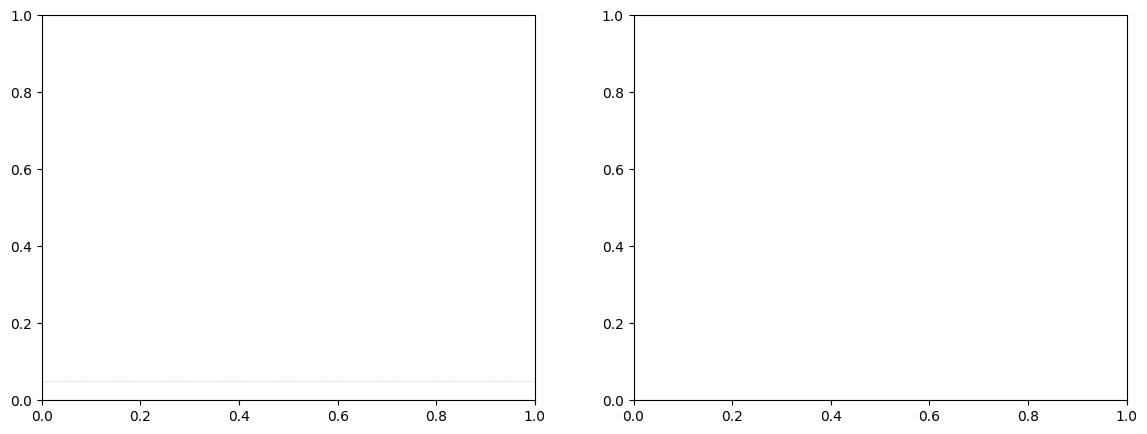

In [25]:
experiment_results = get_experiment_results(config)

# --- 4. Vẽ đồ thị (Visualization) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === BIỂU ĐỒ FPR (Bên trái) ===

# Vẽ đường kẻ alpha mảnh
ax1.axhline(y=alpha, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)

for name, data in experiment_results.items():
    config = methods[name]
    ax1.plot(n_target_list, data["fpr"], 
             label=name, 
             color=config["color"], 
             marker=config["marker"], 
             markersize=1.5,   
             linewidth=0.5)    

# --- XỬ LÝ TRỤC TUNG (Y-AXIS) ---
# 1. Thêm lại số 0.0 vào danh sách ticks chuẩn
standard_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 2. Gộp alpha (0.05) vào danh sách này
fpr_ticks = sorted(list(set(standard_ticks + [alpha])))
ax1.set_yticks(fpr_ticks)

# 3. Hàm định dạng số
def format_func(value, tick_number):
    if abs(value - alpha) < 1e-9: 
        return f'{alpha}' # In ra 0.05
    return f'{value:.1f}' # In ra 0.0, 0.2...

ax1.yaxis.set_major_formatter(FuncFormatter(format_func))

# Thiết lập trục và nhãn
ax1.set_xlabel("# target instances", fontsize=9)
ax1.set_ylabel("FPR", fontsize=9)
ax1.set_xticks(n_target_list)
ax1.tick_params(axis='both', which='major', labelsize=8) 
ax1.set_ylim(-0.02, 1.05) 
ax1.legend(loc="upper right", framealpha=0.9, fontsize=7)
ax1.grid(True, linestyle='--', alpha=0.3, linewidth=0.3)
ax1.set_title("False Positive Rate (FPR)", fontsize=10)

# === BIỂU ĐỒ TPR (Bên phải) ===
for name, data in experiment_results.items():
    config = methods[name]
    ax2.plot(n_target_list, data["tpr"], 
             label=name, 
             color=config["color"], 
             marker=config["marker"],
             markersize=1.5,
             linewidth=0.5)

ax2.set_xlabel("# target instances", fontsize=9)
ax2.set_ylabel("TPR", fontsize=9)
ax2.set_xticks(n_target_list)
# Bên TPR dùng danh sách ticks chuẩn (có số 0.0)
ax2.set_yticks(standard_ticks) 
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_ylim(-0.02, 1.05)
ax2.legend(loc="upper left", framealpha=0.9, fontsize=7)
ax2.grid(True, linestyle='--', alpha=0.3, linewidth=0.3)
ax2.set_title("True Positive Rate (TPR)", fontsize=10)

plt.tight_layout(pad=0.5)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- 4. Vẽ đồ thị (Visualization) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# === BIỂU ĐỒ FPR (Bên trái) ===

# Vẽ đường kẻ alpha mảnh
ax1.axhline(y=alpha, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)

for name, data in experiment_results.items():
    config = methods[name]
    ax1.plot(n_target_list, data["fpr"], 
             label=name, 
             color=config["color"], 
             marker=config["marker"], 
             markersize=1.5,   
             linewidth=0.5)    

# --- XỬ LÝ TRỤC TUNG (Y-AXIS) ---
# 1. Thêm lại số 0.0 vào danh sách ticks chuẩn
standard_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 2. Gộp alpha (0.05) vào danh sách này
fpr_ticks = sorted(list(set(standard_ticks + [alpha])))
ax1.set_yticks(fpr_ticks)

# 3. Hàm định dạng số
def format_func(value, tick_number):
    if abs(value - alpha) < 1e-9: 
        return f'{alpha}' # In ra 0.05
    return f'{value:.1f}' # In ra 0.0, 0.2...

ax1.yaxis.set_major_formatter(FuncFormatter(format_func))

# Thiết lập trục và nhãn
ax1.set_xlabel("# target instances", fontsize=9)
ax1.set_ylabel("FPR", fontsize=9)
ax1.set_xticks(n_target_list)
ax1.tick_params(axis='both', which='major', labelsize=8) 
ax1.set_ylim(-0.02, 1.05) 
ax1.legend(loc="upper right", framealpha=0.9, fontsize=7)
ax1.grid(True, linestyle='--', alpha=0.3, linewidth=0.3)
ax1.set_title("False Positive Rate (FPR)", fontsize=10)

# === BIỂU ĐỒ TPR (Bên phải) ===
for name, data in experiment_results.items():
    config = methods[name]
    ax2.plot(n_target_list, data["tpr"], 
             label=name, 
             color=config["color"], 
             marker=config["marker"],
             markersize=1.5,
             linewidth=0.5)

ax2.set_xlabel("# target instances", fontsize=9)
ax2.set_ylabel("TPR", fontsize=9)
ax2.set_xticks(n_target_list)
# Bên TPR dùng danh sách ticks chuẩn (có số 0.0)
ax2.set_yticks(standard_ticks) 
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_ylim(-0.02, 1.05)
ax2.legend(loc="upper left", framealpha=0.9, fontsize=7)
ax2.grid(True, linestyle='--', alpha=0.3, linewidth=0.3)
ax2.set_title("True Positive Rate (TPR)", fontsize=10)

plt.tight_layout(pad=0.5)
plt.show()